In [31]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [32]:
UNIVERSE = {
    # ── Broad Market Equity ─────────────────────────────────────────────────
    "SPY": "S&P 500 — SPDR (BENCHMARK, inception 1993-01-29)",
    "IVV": "S&P 500 — iShares Core (inception 2000-05-19)",
    "VTI": "Total US Market — Vanguard (inception 2001-06-15)",
    "ITOT": "Total US Market — iShares Core (inception 2004-01-23)",
    # ── Equity Style ────────────────────────────────────────────────────────
    "IWB": "Russell 1000 — iShares Large Blend (2000-05-19)",
    "IWD": "Russell 1000 Value — iShares (2000-05-26)",
    "IWF": "Russell 1000 Growth — iShares (2000-05-26)",
    "IWM": "Russell 2000 — iShares Small Blend (2000-05-26)",
    "IWN": "Russell 2000 Value — iShares (2000-07-28)",
    "IWO": "Russell 2000 Growth — iShares (2000-07-28)",
    "IJH": "S&P 400 Mid-Cap — iShares Core (2000-05-26)",
    "IJJ": "S&P 400 Mid-Cap Value — iShares (2000-07-28)",
    # ── GICS Sectors (all 9 available with 20yr history) ────────────────────
    "XLK": "Information Technology — SPDR (1998-12-22)",
    "XLF": "Financials — SPDR (1998-12-22)",
    "XLV": "Health Care — SPDR (1998-12-22)",
    "XLE": "Energy — SPDR (1998-12-22)",
    "XLI": "Industrials — SPDR (1998-12-22)",
    "XLY": "Consumer Discretionary — SPDR (1998-12-22)",
    "XLP": "Consumer Staples — SPDR (1998-12-22)",
    "XLU": "Utilities — SPDR (1998-12-22)",
    "XLB": "Materials — SPDR (1998-12-22)",
    # ── Fixed Income ────────────────────────────────────────────────────────
    "SHY": "US Treasury 1–3Y — iShares (2002-07-30)",
    "IEF": "US Treasury 7–10Y — iShares (2002-07-30)",
    "TLT": "US Treasury 20+Y — iShares (2002-07-30)",
    "LQD": "IG Corporate — iShares iBoxx $ (2002-07-30)",
    "AGG": "US Aggregate Bond — iShares Core (2003-09-29)",
    "TIP": "TIPS — iShares (2003-12-05)",
    # ── Real Estate ─────────────────────────────────────────────────────────
    # "IYR":  "US Real Estate — iShares DJ (2000-06-19)",
    # "VNQ":  "US REITs — Vanguard (2004-09-29)",
    # ── Real Assets / Commodities ────────────────────────────────────────────
    # "GLD":  "Gold — SPDR Gold Shares (2004-11-18)",
    # "IAU":  "Gold — iShares Gold Trust (2005-01-28)",
    # "USO":  "Crude Oil — US Oil Fund (2006-04-10)",
    # ── Smart Beta (with 20yr history) ──────────────────────────────────────
    # "SPHQ": "S&P 500 Quality — Invesco (2005-12-06)",
}

tickers = list(UNIVERSE.keys())  # 33 ETFs

start_date = "2000-01-01"

end_date = None  # latest available

In [33]:
raw = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    actions=True,
    progress=False,
    group_by="ticker",
)
raw = raw.sort_index()

raw = raw[~raw.index.duplicated(keep="first")]

In [34]:
adj_close = raw.xs("Adj Close", axis=1, level=1)

close = raw.xs("Close", axis=1, level=1)

volume = raw.xs("Volume", axis=1, level=1)

dividends = raw.xs("Dividends", axis=1, level=1)

splits = raw.xs("Stock Splits", axis=1, level=1)

In [35]:
summary = []

for t in tickers:

    s = adj_close[t].dropna()

    summary.append(
        {
            "ticker": t,
            "first_valid_date": s.index.min(),
            "last_valid_date": s.index.max(),
            "num_obs": s.shape[0],
        }
    )

summary_df = (
    pd.DataFrame(summary).sort_values("first_valid_date").reset_index(drop=True)
)

common_start = summary_df["first_valid_date"].max()

common_end = summary_df["last_valid_date"].min()

print("Common start:", common_start)

print("Common end:", common_end)

print(summary_df)

Common start: 2004-01-23 00:00:00
Common end: 2026-04-17 00:00:00
   ticker first_valid_date last_valid_date  num_obs
0     SPY       2000-01-03      2026-04-17     6612
1     XLB       2000-01-03      2026-04-17     6612
2     XLU       2000-01-03      2026-04-17     6612
3     XLP       2000-01-03      2026-04-17     6612
4     XLY       2000-01-03      2026-04-17     6612
5     XLI       2000-01-03      2026-04-17     6612
6     XLE       2000-01-03      2026-04-17     6612
7     XLV       2000-01-03      2026-04-17     6612
8     XLK       2000-01-03      2026-04-17     6612
9     XLF       2000-01-03      2026-04-17     6612
10    IWB       2000-05-19      2026-04-17     6516
11    IVV       2000-05-19      2026-04-17     6516
12    IJH       2000-05-26      2026-04-17     6511
13    IWM       2000-05-26      2026-04-17     6511
14    IWF       2000-05-26      2026-04-17     6511
15    IWD       2000-05-26      2026-04-17     6511
16    IJJ       2000-07-28      2026-04-17     646

In [36]:
adj_close_common = adj_close.loc[common_start:common_end].copy()

close_common = close.loc[common_start:common_end].copy()

volume_common = volume.loc[common_start:common_end].copy()

dividends_common = dividends.loc[common_start:common_end].copy()

splits_common = splits.loc[common_start:common_end].copy()

In [37]:
missing_report = adj_close_common.isna().sum().rename("missing_adj_close")

print("\nMissing adjusted close inside common window:")

print(missing_report)

# strict rule: keep only ETFs with complete adjusted close data

complete_tickers = adj_close_common.columns[adj_close_common.notna().all()].tolist()

dropped_tickers = sorted(list(set(tickers) - set(complete_tickers)))

print("\nComplete tickers:", complete_tickers)

print("Dropped tickers:", dropped_tickers)

adj_close_clean = adj_close_common[complete_tickers].copy()


Missing adjusted close inside common window:
Ticker
IWM     0
AGG     0
SPY     0
IJH     0
XLV     0
IJJ     0
LQD     0
IWN     0
XLF     0
IVV     0
XLB     0
XLK     0
XLI     0
XLE     0
SHY     0
XLP     0
VTI     0
IEF     0
IWD     0
TIP     0
TLT     0
XLU     0
ITOT    0
IWF     0
XLY     0
IWO     0
IWB     0
Name: missing_adj_close, dtype: int64

Complete tickers: ['IWM', 'AGG', 'SPY', 'IJH', 'XLV', 'IJJ', 'LQD', 'IWN', 'XLF', 'IVV', 'XLB', 'XLK', 'XLI', 'XLE', 'SHY', 'XLP', 'VTI', 'IEF', 'IWD', 'TIP', 'TLT', 'XLU', 'ITOT', 'IWF', 'XLY', 'IWO', 'IWB']
Dropped tickers: []


In [38]:
daily_log_ret = np.log(adj_close_clean / adj_close_clean.shift(1))

daily_log_ret = daily_log_ret.replace([np.inf, -np.inf], np.nan)

daily_log_ret = daily_log_ret.dropna(how="all")

In [39]:
large_move_report = (daily_log_ret.abs() > 0.5).sum().rename("num_abs_logret_gt_0.5")

print("\nLarge daily move report:")

print(large_move_report)


Large daily move report:
Ticker
IWM     0
AGG     0
SPY     0
IJH     0
XLV     0
IJJ     0
LQD     0
IWN     0
XLF     0
IVV     0
XLB     0
XLK     0
XLI     0
XLE     0
SHY     0
XLP     0
VTI     0
IEF     0
IWD     0
TIP     0
TLT     0
XLU     0
ITOT    0
IWF     0
XLY     0
IWO     0
IWB     0
Name: num_abs_logret_gt_0.5, dtype: int64


In [40]:
weekly_log_ret = daily_log_ret.resample("W-FRI").sum()

monthly_log_ret = daily_log_ret.resample("ME").sum()

In [41]:
summary_df.to_csv("summary_by_ticker.csv", index=False)

adj_close_clean.to_csv("adj_close_clean.csv")

daily_log_ret.to_csv("daily_log_returns.csv")

weekly_log_ret.to_csv("weekly_log_returns.csv")

monthly_log_ret.to_csv("monthly_log_returns.csv")

print("\nFiles saved:")

print("summary_by_ticker.csv")

print("adj_close_clean.csv")

print("daily_log_returns.csv")

print("weekly_log_returns.csv")

print("monthly_log_returns.csv")


Files saved:
summary_by_ticker.csv
adj_close_clean.csv
daily_log_returns.csv
weekly_log_returns.csv
monthly_log_returns.csv


In [42]:
R = monthly_log_ret

In [43]:
mean = R.mean(axis=1)
std = R.std(axis=1)

z_ret = R.sub(mean, axis=0).div(std, axis=0)

z_ret = z_ret.clip(-3, 3)
z_ret = z_ret.dropna()

In [44]:
z_ret.isna().sum()

Ticker
IWM     0
AGG     0
SPY     0
IJH     0
XLV     0
IJJ     0
LQD     0
IWN     0
XLF     0
IVV     0
XLB     0
XLK     0
XLI     0
XLE     0
SHY     0
XLP     0
VTI     0
IEF     0
IWD     0
TIP     0
TLT     0
XLU     0
ITOT    0
IWF     0
XLY     0
IWO     0
IWB     0
dtype: int64

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

factors = pca.fit_transform(z_ret)

factor_df = pd.DataFrame(
    factors, index=z_ret.index, columns=["Factor_1", "Factor_2", "Factor_3"]
)

loadings = pd.DataFrame(
    pca.components_.T, index=z_ret.columns, columns=["Factor_1", "Factor_2", "Factor_3"]
)

explained_var = pca.explained_variance_ratio_

In [46]:
loadings

,Factor_1,Factor_2,Factor_3
Ticker,,,
IWM,-0.219267,0.011989,0.353092
AGG,0.286165,0.032064,0.117125
SPY,-0.063386,-0.089429,-0.127248
IJH,-0.147914,0.030578,0.119658
XLV,0.059865,-0.090544,-0.291261
IJJ,-0.158167,0.086305,0.104545
LQD,0.262654,0.008527,0.089457
IWN,-0.203176,0.099482,0.299409
XLF,-0.156927,-0.036392,-0.232092


In [47]:
explained_var

array([0.36653761, 0.15499489, 0.09581115])

In [48]:
factor_df.head()

,Factor_1,Factor_2,Factor_3
Date,,,
2004-01-31,3.776196,-0.116257,-3.125958
2004-02-29,0.689364,3.231396,-1.095110
2004-03-31,2.719748,1.506673,3.419107
2004-04-30,0.263038,0.935544,-2.756017
2004-05-31,-2.688792,-1.346581,0.719146


In [49]:
stats = factor_df.agg(["mean", "std", "skew", "kurt"])
stats

,Factor_1,Factor_2,Factor_3
mean,-1.988459e-17,0.000000,-6.628197e-18
std,3.023722e+00,1.966261,1.545933e+00
skew,2.948420e-01,0.047507,-3.935019e-02
kurt,-1.245485e+00,-0.766283,-3.737947e-01


In [50]:
factor_cov = factor_df.cov()
factor_cov

,Factor_1,Factor_2,Factor_3
Factor_1,9.142894e+00,-1.197544e-16,1.004606e-15
Factor_2,-1.197544e-16,3.866184e+00,-9.846472e-16
Factor_3,1.004606e-15,-9.846472e-16,2.389908e+00


In [51]:
ewma_var = factor_df.ewm(span=20).var()
ewma_vol = np.sqrt(ewma_var)

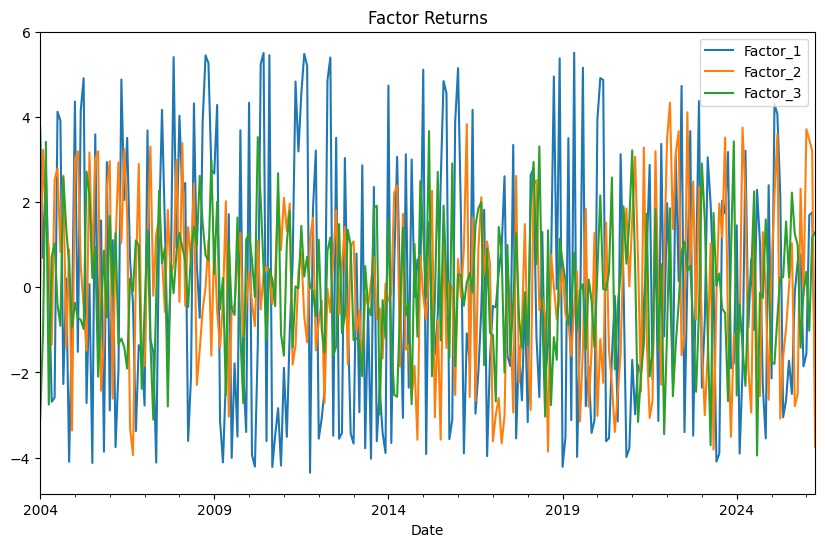

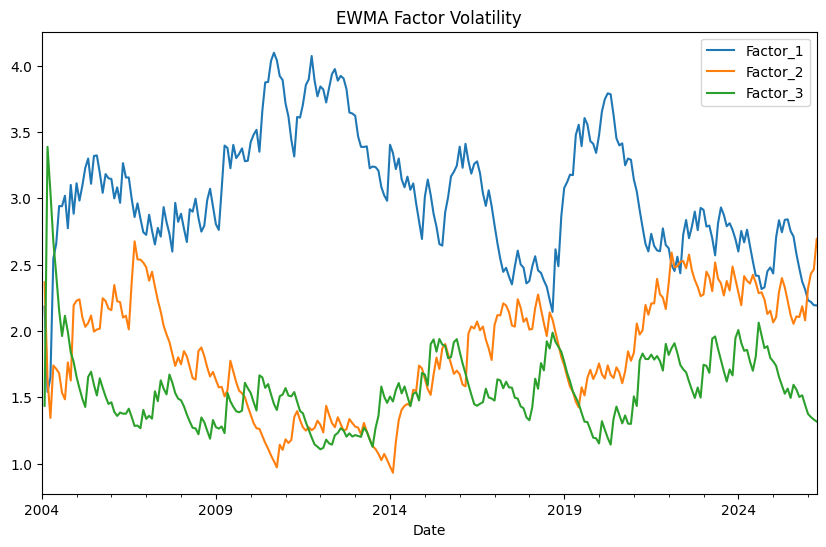

In [52]:
factor_df.plot(figsize=(10, 6), title="Factor Returns")

plt.show()

ewma_vol.plot(figsize=(10, 6), title="EWMA Factor Volatility")

plt.show()

In [53]:
from arch import arch_model

garch_results = {}

for col in factor_df.columns:

    # series = factor_df[col].dropna() * 10
    series = factor_df[col].dropna()
    series = series / series.std()

    am = arch_model(series, vol="Garch", p=1, q=1, dist="t")

    res = am.fit(disp="off")

    garch_results[col] = res

    print(f"\n{col}")

    print(res.summary())


Factor_1
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                     Factor_1   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -377.744
Distribution:      Standardized Student's t   AIC:                           765.487
Method:                  Maximum Likelihood   BIC:                           783.442
                                              No. Observations:                  268
Date:                      Sun, Apr 19 2026   Df Residuals:                      267
Time:                              14:52:21   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu    

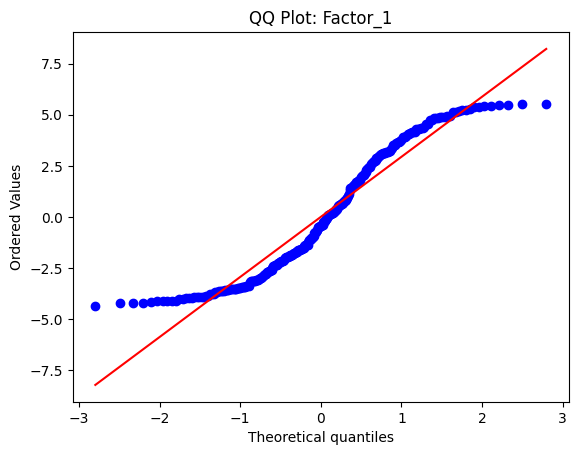

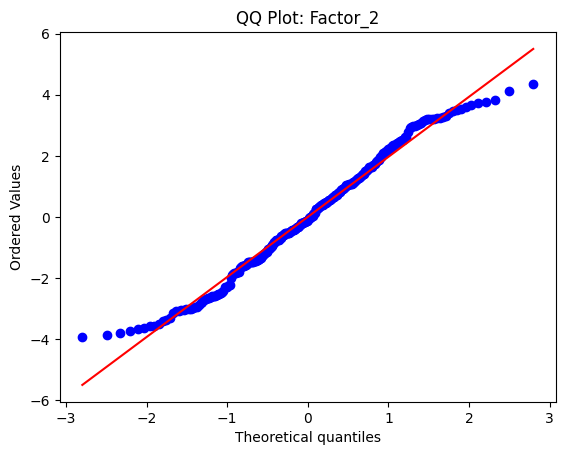

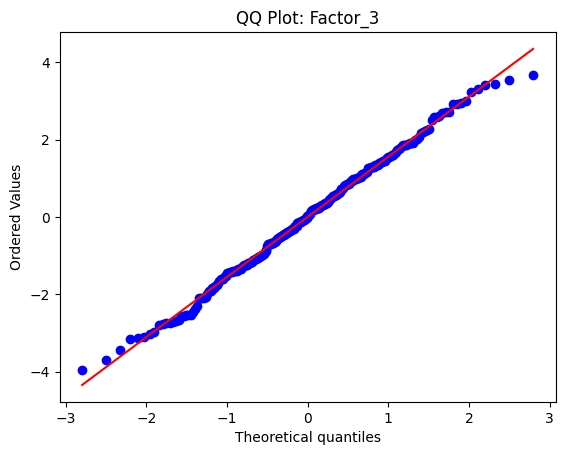

In [54]:
import scipy.stats as stats

for col in factor_df.columns:

    stats.probplot(factor_df[col], dist="norm", plot=plt)

    plt.title(f"QQ Plot: {col}")

    plt.show()

In [55]:
tail_stats = {}

for col in factor_df.columns:

    x = factor_df[col].dropna()

    q05 = x.quantile(0.05)

    left_tail = x[x <= q05]

    tail_stats[col] = {
        "5% quantile": q05,
        "tail mean": left_tail.mean(),
        "tail std": left_tail.std(),
        "min": x.min(),
    }

tail_df = pd.DataFrame(tail_stats).T

tail_df

,5% quantile,tail mean,tail std,min
Factor_1,-3.978064,-4.125703,0.106242,-4.356421
Factor_2,-3.076286,-3.545146,0.259308,-3.941649
Factor_3,-2.680288,-3.071584,0.391750,-3.952751


In [56]:
def parallel_analysis(df, n_iter=1000, random_state=42, percentile=95):
    """

    Parallel Analysis on a dataframe (rows=time, cols=assets).



    Parameters

    ----------

    df : pd.DataFrame

        Input matrix for factor analysis / PCA.

    n_iter : int

        Number of random simulations.

    random_state : int

        Seed for reproducibility.

    percentile : int

        Percentile of simulated eigenvalues to use as threshold.

        95 is common and more conservative than the mean.



    Returns

    -------

    results : pd.DataFrame

        Table of actual eigenvalues, mean random eigenvalues,

        percentile random eigenvalues, and retain decision.

    """

    rng = np.random.default_rng(random_state)

    X = df.dropna().values

    n_obs, n_vars = X.shape

    # Correlation matrix of actual data

    corr_actual = np.corrcoef(X, rowvar=False)

    eig_actual = np.linalg.eigvalsh(corr_actual)[::-1]  # descending

    # Simulated random eigenvalues

    rand_eigs = np.zeros((n_iter, n_vars))

    for i in range(n_iter):

        X_rand = rng.normal(size=(n_obs, n_vars))

        corr_rand = np.corrcoef(X_rand, rowvar=False)

        eig_rand = np.linalg.eigvalsh(corr_rand)[::-1]

        rand_eigs[i, :] = eig_rand

    eig_rand_mean = rand_eigs.mean(axis=0)

    eig_rand_pct = np.percentile(rand_eigs, percentile, axis=0)

    retain = eig_actual > eig_rand_pct

    results = pd.DataFrame(
        {
            "Factor": np.arange(1, n_vars + 1),
            "Actual_Eigenvalue": eig_actual,
            "Random_Mean": eig_rand_mean,
            f"Random_P{percentile}": eig_rand_pct,
            "Retain": retain,
        }
    )

    return results

In [57]:
pa_results = parallel_analysis(z_ret, n_iter=1000, random_state=42, percentile=95)
pa_results

,Factor,Actual_Eigenvalue,Random_Mean,Random_P95,Retain
0,1,11.020757,1.634696,1.723462,True
1,2,4.978654,1.538056,1.608029,True
2,3,2.690127,1.466080,1.524901,True
3,4,1.410754,1.403471,1.453856,False
4,5,1.194004,1.347752,1.395148,False
5,6,1.099870,1.296254,1.340420,False
6,7,0.927536,1.248197,1.288118,False
7,8,0.710776,1.203574,1.242638,False
8,9,0.618945,1.161728,1.197696,False
9,10,0.449080,1.120184,1.155362,False


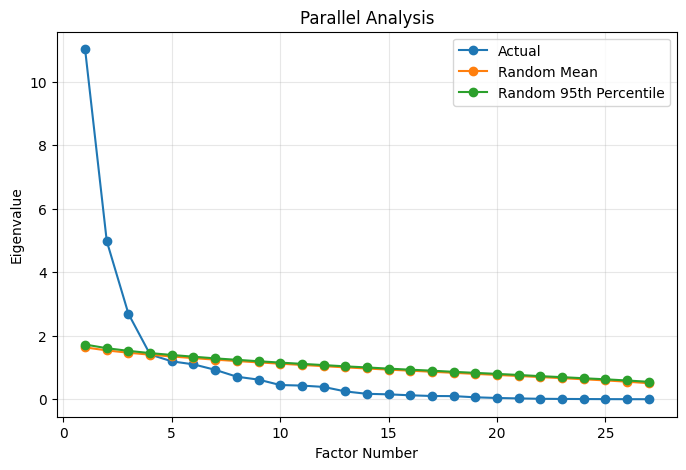

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(
    pa_results["Factor"], pa_results["Actual_Eigenvalue"], marker="o", label="Actual"
)
plt.plot(
    pa_results["Factor"], pa_results["Random_Mean"], marker="o", label="Random Mean"
)
plt.plot(
    pa_results["Factor"],
    pa_results["Random_P95"],
    marker="o",
    label="Random 95th Percentile",
)
plt.xlabel("Factor Number")
plt.ylabel("Eigenvalue")
plt.title("Parallel Analysis")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
carry = pd.read_csv("Carry_ZScore.csv", index_col=0, parse_dates=True)

value = pd.read_csv("Value_ZScore.csv", index_col=0, parse_dates=True)

mom = pd.read_csv("MOM_ZScore.csv", index_col=0, parse_dates=True)

quality = pd.read_csv("Quality_ZScore.csv", index_col=0, parse_dates=True)

In [66]:
def long_short_factor(df, q=0.3):
    q_high = df.quantile(1 - q, axis=1)
    q_low = df.quantile(q, axis=1)

    long = df.where(df.ge(q_high, axis=0))
    short = df.where(df.le(q_low, axis=0))

    return long.mean(axis=1) - short.mean(axis=1)

In [67]:
style_df = pd.DataFrame(
    {
        "Carry": long_short_factor(carry),
        "Value": long_short_factor(value),
        "Momentum": long_short_factor(mom),
        "Quality": long_short_factor(quality),
    }
)

In [68]:
style_df.head()

,Carry,Value,Momentum,Quality
Date,,,,
2006-04-30,2.099595,NaN,2.421885,NaN
2006-05-31,2.098876,NaN,2.397335,NaN
2006-06-30,2.126879,NaN,2.302488,NaN
2006-07-31,2.145194,NaN,2.271555,NaN
2006-08-31,2.151207,NaN,2.130652,NaN


In [69]:
style_df.index[:5]

DatetimeIndex(['2006-04-30', '2006-05-31', '2006-06-30', '2006-07-31',
               '2006-08-31'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [65]:
style_df.shape

(240, 4)

In [70]:
style_df = style_df.dropna()

In [71]:
style_df.head()

,Carry,Value,Momentum,Quality
Date,,,,
2007-01-31,2.187440,1.914201,2.355988,2.280323
2007-02-28,2.184739,1.961831,2.378805,2.243676
2007-03-31,2.132597,1.924466,2.266673,2.279918
2007-04-30,2.123398,1.938400,2.020097,2.221650
2007-05-31,2.110152,1.926540,2.121750,2.257005


In [72]:
common_index = factor_df.index.intersection(style_df.index)

F = factor_df.loc[common_index]
S = style_df.loc[common_index]

In [74]:
corr_style = pd.DataFrame(index=F.columns, columns=S.columns, dtype=float)

for f_col in F.columns:
    for s_col in S.columns:
        corr_style.loc[f_col, s_col] = F[f_col].corr(S[s_col])

corr_style

,Carry,Value,Momentum,Quality
Factor_1,0.030366,-0.084137,-0.098026,-0.045351
Factor_2,0.034405,-0.040281,0.002654,-0.125189
Factor_3,-0.027170,-0.024340,-0.122408,-0.119301


In [75]:
mapping = {}

for factor in corr_style.index:
    best_style = corr_style.loc[factor].abs().idxmax()
    best_corr = corr_style.loc[factor, best_style]

    mapping[factor] = {"Best_Style_Factor": best_style, "Correlation": best_corr}

mapping_df = pd.DataFrame(mapping).T
mapping_df

,Best_Style_Factor,Correlation
Factor_1,Momentum,-0.098026
Factor_2,Quality,-0.125189
Factor_3,Momentum,-0.122408


The latend factors are not matching the style factors

In [81]:
macro_cols = [
    "SPY",  # equity
    "TLT",  # long rate
    "IEF",  # mid rate
    "LQD",  # credit
    "TIP",  # inflation
    "XLE",  # energy
    "XLK",  # tech
    "XLU",  # defensive
]

macro_df = monthly_log_ret[macro_cols].copy()

In [82]:
common_index = factor_df.index.intersection(macro_df.index)

F = factor_df.loc[common_index].copy()
M = macro_df.loc[common_index].copy()

In [83]:
corr_macro = pd.DataFrame(index=F.columns, columns=M.columns, dtype=float)

for f_col in F.columns:
    for m_col in M.columns:
        corr_macro.loc[f_col, m_col] = F[f_col].corr(M[m_col])

corr_macro = corr_macro.astype(float).round(3)

print("=== Latent Factors vs Macro ETFs ===")
print(corr_macro)

=== Latent Factors vs Macro ETFs ===
Ticker      SPY    TLT    IEF    LQD    TIP    XLE    XLK    XLU
Factor_1 -0.782  0.408  0.407 -0.047  0.078 -0.587 -0.701 -0.191
Factor_2 -0.170 -0.236 -0.216 -0.158 -0.072  0.571 -0.369  0.024
Factor_3 -0.206  0.187  0.175  0.037  0.071 -0.100 -0.081 -0.346


In [84]:
macro_mapping = {}

for factor in corr_macro.index:
    best_macro = corr_macro.loc[factor].abs().idxmax()
    best_corr = corr_macro.loc[factor, best_macro]

    macro_mapping[factor] = {"Best_Macro_Proxy": best_macro, "Correlation": best_corr}

macro_mapping_df = pd.DataFrame(macro_mapping).T

print("\n=== Best Macro Match ===")
print(macro_mapping_df)


=== Best Macro Match ===
         Best_Macro_Proxy Correlation
Factor_1              SPY      -0.782
Factor_2              XLE       0.571
Factor_3              XLU      -0.346


* Factor 1: Risk-Off / Broad Equity Factor
* Factor 2: Energy / Sector Rotation Factor
* Factor 3: Defensive / Utilities–Rates Factor

The first latent factor is strongly associated with broad equity and growth-sensitive exposures, showing large negative correlations with SPY and XLK and weaker positive correlations with duration proxies, consistent with a risk-off or equity drawdown factor.

The second latent factor is most strongly linked to XLE and negatively associated with XLK, suggesting an energy- or inflation-sensitive sector rotation factor.

The third latent factor is moderately related to defensive utilities exposure and weakly positively related to Treasury duration, consistent with a defensive or utilities–rates factor.